In [1]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [5]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.80050009  1.06548848  1.29708846  0.45984057 -0.92974581 -0.73206462
  -0.91245053 -0.05449919  0.41853093 -0.37098854]
 [-0.03956713 -0.93853666 -1.08218016 -0.55350458 -0.17762425 -0.40288615
   1.56441355 -0.83030083 -1.43658851 -1.93847913]
 [ 1.79330681  1.06548848  0.93453324 -0.1192138  -0.95867356 -0.71889748
  -0.68024452 -0.05449919  0.06015558 -0.54515416]
 [-1.87244107 -0.93853666 -0.24377122 -0.77064997  0.25629203  0.52539714
  -0.75764652  0.72130245  0.47698252 -0.19682291]
 [ 0.11317236 -0.93853666 -0.76494435  0.45984057  0.08272552  0.32789006
   0.17117751 -0.05449919 -0.67250161 -0.98056821]]


In [7]:
alphas = np.logspace(-4, 4, 100)

print(alphas[:10])

[0.0001     0.00012045 0.00014508 0.00017475 0.00021049 0.00025354
 0.00030539 0.00036784 0.00044306 0.00053367]


In [8]:
ridge_coeffs = []
lasso_coeffs = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    ridge_coeffs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    lasso_coeffs.append(lasso.coef_)

In [9]:
ridge_coeffs = np.array(ridge_coeffs)
lasso_coeffs = np.array(lasso_coeffs)

print(ridge_coeffs.shape)
print(lasso_coeffs.shape)

(100, 10)
(100, 10)


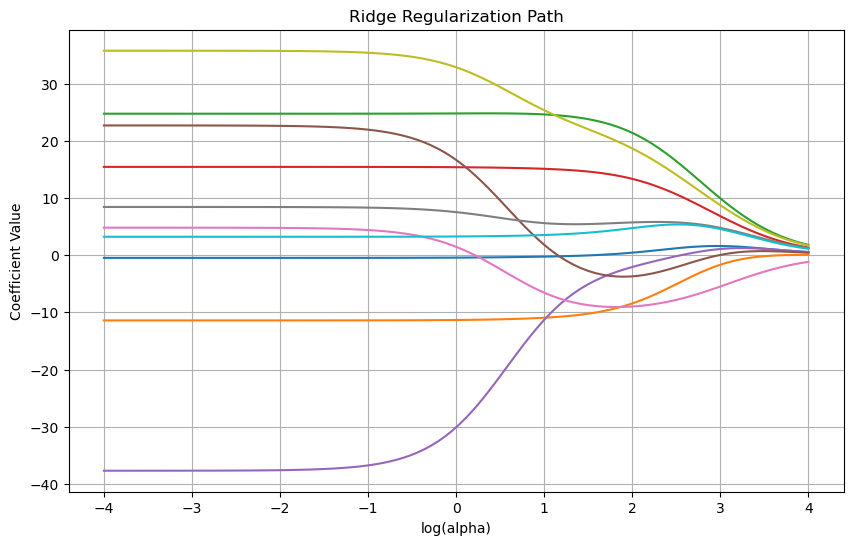

In [10]:
plt.figure(figsize=(10,6))

for i in range(X.shape[1]):
    plt.plot(np.log10(alphas), ridge_coeffs[:, i])

plt.xlabel("log(alpha)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regularization Path")
plt.grid(True)

plt.show()

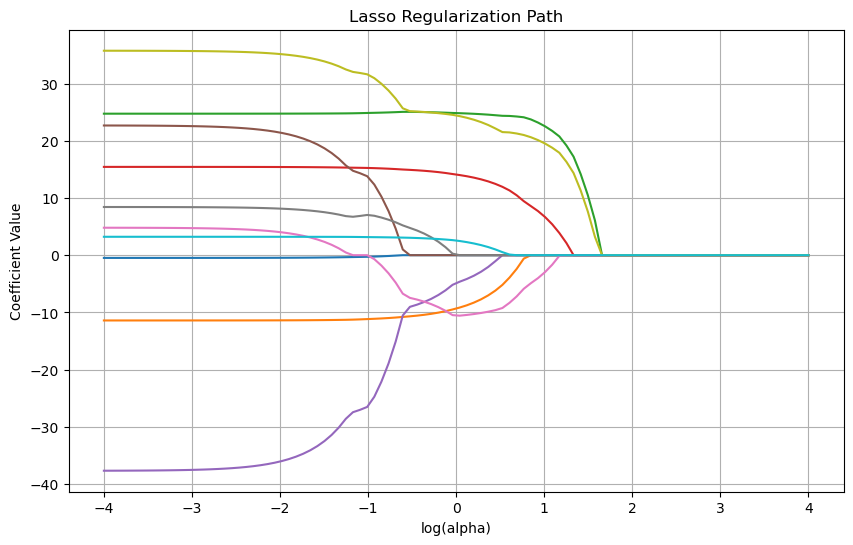

In [11]:
plt.figure(figsize=(10,6))

for i in range(X.shape[1]):
    plt.plot(np.log10(alphas), lasso_coeffs[:, i])

plt.xlabel("log(alpha)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regularization Path")
plt.grid(True)

plt.show()

In [12]:
for alpha, coef in zip(alphas, lasso_coeffs):

    if np.any(coef == 0):
        print("First feature eliminated at alpha =", alpha)
        break

First feature eliminated at alpha = 0.06734150657750829


In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [14]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (569, 30)
y Shape: (569,)


In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [16]:
param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear']
}

In [17]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

In [18]:
grid_search.fit(X, y)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [19]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [20]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [21]:
print("Mean Cross-Validated Score:")
print(grid_search.best_score_)

Mean Cross-Validated Score:
0.9824406148113647
